In [3]:
import sys
import os
import pandas as pd

import onionnet
print("onionnet package located at:", onionnet.__file__)
from onionnet import OnionNet


onionnet package located at: /Users/agjanyunlu/Documents/Metabolomics/onionnet/onionnet/__init__.py


In [4]:
onion = OnionNet()

In [10]:
df_swisslipids_nodes = pd.read_csv('data/df_swisslipids_nodes.tsv', sep='\t', low_memory=False, dtype=str)
df_swisslipids_edges = pd.read_csv('data/df_swisslipids_edges.tsv', sep='\t', low_memory=False, dtype=str)

In [11]:
df_swisslipids_edges

,source_layer,source_id,target_layer,target_id,interlayer
0,swisslipids,SLM:000000002,chebi,70846,True
1,swisslipids,SLM:000000003,chebi,70771,True
2,swisslipids,SLM:000000006,chebi,70829,True
3,swisslipids,SLM:000000007,chebi,70775,True
4,swisslipids,SLM:000000035,chebi,57817,True
...,...,...,...,...,...
4676203,swisslipids,SLM:000508864,swisslipids,SLM:000782324,False
4676204,swisslipids,SLM:000508864,swisslipids,SLM:000782325,False
4676205,swisslipids,SLM:000508864,swisslipids,SLM:000782326,False
4676206,swisslipids,SLM:000782238,swisslipids,SLM:000782327,False


In [8]:
df_swisslipids_nodes

,layer,node_id,Lipid ID,Level,Name,Abbreviation*,CHEBI,LIPID MAPS,HMDB,MetaNetX,PMID,Lipid class*
0,chebi,10036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,chebi,10362,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chebi,111515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,chebi,11152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,chebi,1156,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1319417,swisslipids,SLM:000782329,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1319418,swisslipids,SLM:000782330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1319419,swisslipids,SLM:000782331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1319420,swisslipids,SLM:000782332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
from lipinet.network import OnionNet
from graph_tool import Graph, GraphView

onion = OnionNet()

onion.grow_onion(df_nodes=df_swisslipids_nodes,
           df_edges=df_swisslipids_edges,
           node_prop_cols=df_swisslipids_nodes.columns.to_list(), #.drop(labels=['layer','node_id']).to_list()
           edge_prop_cols=df_swisslipids_edges.columns.to_list(),
           drop_na=True,
           drop_duplicates=True)

,layer,node_id,Lipid ID,Level,Name,Abbreviation*,CHEBI,LIPID MAPS,HMDB,MetaNetX,PMID,Lipid class*
0,chebi,10036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,chebi,10362,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chebi,111515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,chebi,11152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,chebi,1156,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nodes DataFrame Shape: (1319303, 12)



,source_layer,source_id,target_layer,target_id,interlayer
0,swisslipids,SLM:000000002,chebi,70846,True
1,swisslipids,SLM:000000003,chebi,70771,True
2,swisslipids,SLM:000000006,chebi,70829,True
3,swisslipids,SLM:000000007,chebi,70775,True
4,swisslipids,SLM:000000035,chebi,57817,True


Edges DataFrame Shape: (4675613, 5)


Graph Summary:
Number of Vertices: 1319297
Number of Edges: 1329020
Number of Vertex Properties: 14
Number of Edge Properties: 5
Vertex Properties:
  - layer_hash
  - node_id_hash
  - layer
  - node_id
  - Lipid ID
  - Level
  - Name
  - Abbreviation*
  - CHEBI
  - LIPID MAPS
  - HMDB
  - MetaNetX
  - PMID
  - Lipid class*
Edge Properties:
  - source_layer
  - source_id
  - target_layer
  - target_id
  - interlayer

Vertex Properties:


,Property Name,Type
0,layer_hash,int64_t
1,node_id_hash,int64_t
2,layer,int32_t
3,node_id,int32_t
4,Lipid ID,int32_t
5,Level,int32_t
6,Name,int32_t
7,Abbreviation*,int32_t
8,CHEBI,int32_t
9,LIPID MAPS,int32_t



Edge Properties:


,Property Name,Type
0,source_layer,int32_t
1,source_id,int32_t
2,target_layer,int32_t
3,target_id,int32_t
4,interlayer,int32_t


In [15]:
list(onion.graph.properties)

[('v', 'layer_hash'),
 ('v', 'node_id_hash'),
 ('v', 'layer'),
 ('v', 'node_id'),
 ('v', 'Lipid ID'),
 ('v', 'Level'),
 ('v', 'Name'),
 ('v', 'Abbreviation*'),
 ('v', 'CHEBI'),
 ('v', 'LIPID MAPS'),
 ('v', 'HMDB'),
 ('v', 'MetaNetX'),
 ('v', 'PMID'),
 ('v', 'Lipid class*'),
 ('e', 'source_layer'),
 ('e', 'source_id'),
 ('e', 'target_layer'),
 ('e', 'target_id'),
 ('e', 'interlayer')]

In [16]:
onion.layer_code_to_name

{0: 'chebi',
 1: 'hmdb',
 2: 'lipidmaps',
 3: 'metanetx',
 4: 'pmid',
 5: 'swisslipids'}

In [17]:
chebi_layer = onion.view_layers(layer_names='chebi')
chebi_layer

<GraphView object, directed, with 4276 vertices and 0 edges, 14 internal vertex properties, 5 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x328d8eae0, at 0x15bb71490>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x328d8eae0, at 0x3573d6540>, False), at 0x328d8eae0>

In [20]:
hmdb_layer = onion.view_layers(layer_names='hmdb')
hmdb_layer

<GraphView object, directed, with 17232 vertices and 0 edges, 14 internal vertex properties, 5 internal edge properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x328d8cf20, at 0x328d8cbc0>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x328d8cf20, at 0x169476ab0>, False), at 0x328d8cf20>

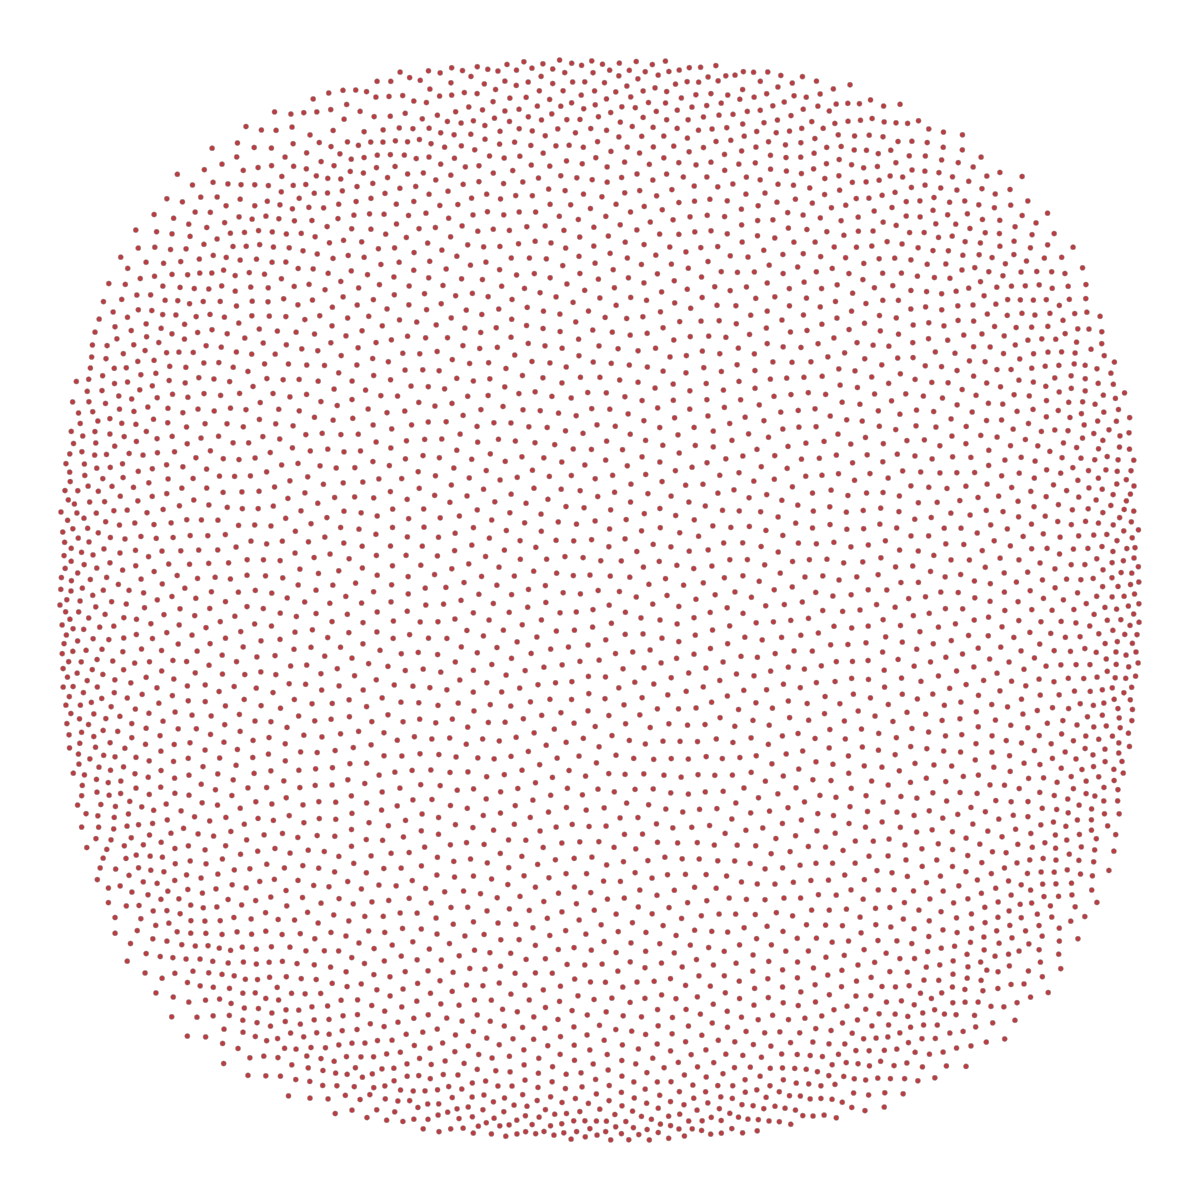

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x328d8eae0, at 0x1694a5fa0>

In [19]:
from graph_tool.all import graph_draw

graph_draw(chebi_layer)

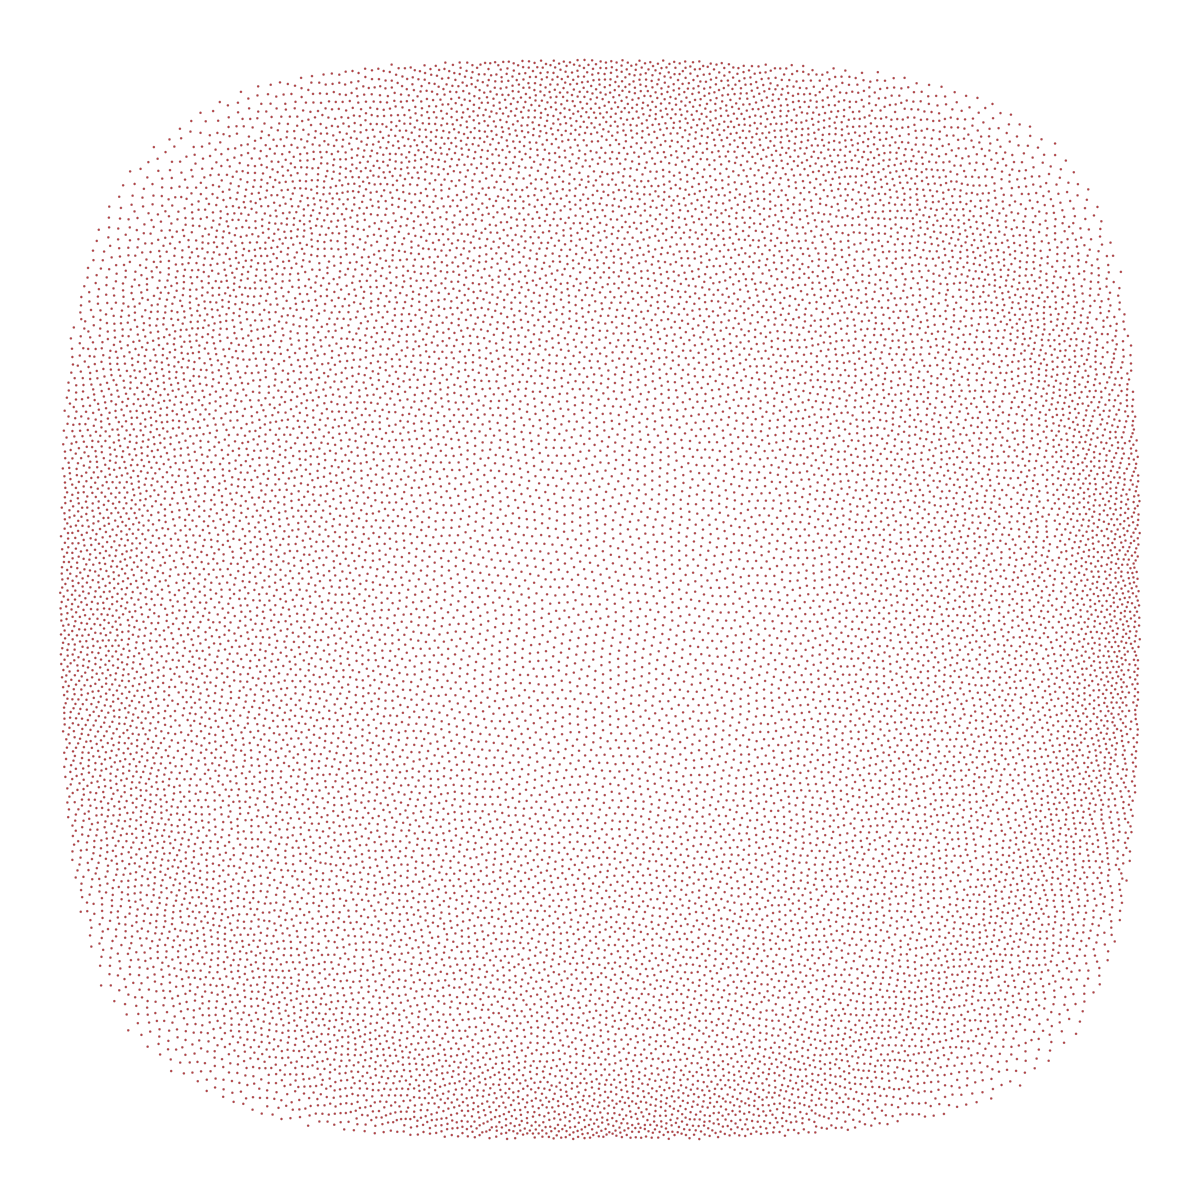

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x169477dd0, at 0x10780f5f0>

In [21]:
graph_draw(onion.view_layers(layer_names=['hmdb','chebi']))

Also create a mini version

In [31]:
# Step 1: Sample a subset of edges.
df_edges_mini = df_swisslipids_edges.sample(n=10000, random_state=42)

# Step 2: Extract unique node IDs from the sampled edges.
sample_node_ids = set(df_edges_mini['source_id']).union(set(df_edges_mini['target_id']))

# Step 3: Filter the nodes DataFrame to include only those nodes.
df_nodes_mini = df_swisslipids_nodes[df_swisslipids_nodes['node_id'].isin(sample_node_ids)]

# Now create the mini onion.
onion_mini = OnionNet()

onion_mini.grow_onion(
    df_nodes=df_nodes_mini,
    df_edges=df_edges_mini,
    node_prop_cols=df_nodes_mini.columns.to_list(),
    edge_prop_cols=df_edges_mini.columns.to_list(),
    drop_na=True,
    drop_duplicates=True
)

,layer,node_id,Lipid ID,Level,Name,Abbreviation*,CHEBI,LIPID MAPS,HMDB,MetaNetX,PMID,Lipid class*
514,chebi,138734,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
762,chebi,141690,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1488,chebi,52320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2695,chebi,75207,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4276,chebi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nodes DataFrame Shape: (11322, 12)



,source_layer,source_id,target_layer,target_id,interlayer
2278670,swisslipids,SLM:000722682,hmdb,NaN,True
2673073,swisslipids,SLM:000336922,metanetx,MNXM533019,True
2323646,swisslipids,SLM:000767787,hmdb,NaN,True
2116281,swisslipids,SLM:000560275,hmdb,NaN,True
4762,swisslipids,SLM:000005224,chebi,NaN,True


Edges DataFrame Shape: (10000, 5)


Graph Summary:
Number of Vertices: 11316
Number of Edges: 2869
Number of Vertex Properties: 14
Number of Edge Properties: 5
Vertex Properties:
  - layer_hash
  - node_id_hash
  - layer
  - node_id
  - Lipid ID
  - Level
  - Name
  - Abbreviation*
  - CHEBI
  - LIPID MAPS
  - HMDB
  - MetaNetX
  - PMID
  - Lipid class*
Edge Properties:
  - source_layer
  - source_id
  - target_layer
  - target_id
  - interlayer

Vertex Properties:


,Property Name,Type
0,layer_hash,int64_t
1,node_id_hash,int64_t
2,layer,int32_t
3,node_id,int32_t
4,Lipid ID,int32_t
5,Level,int32_t
6,Name,int32_t
7,Abbreviation*,int32_t
8,CHEBI,int32_t
9,LIPID MAPS,int32_t



Edge Properties:


,Property Name,Type
0,source_layer,int32_t
1,source_id,int32_t
2,target_layer,int32_t
3,target_id,int32_t
4,interlayer,int32_t


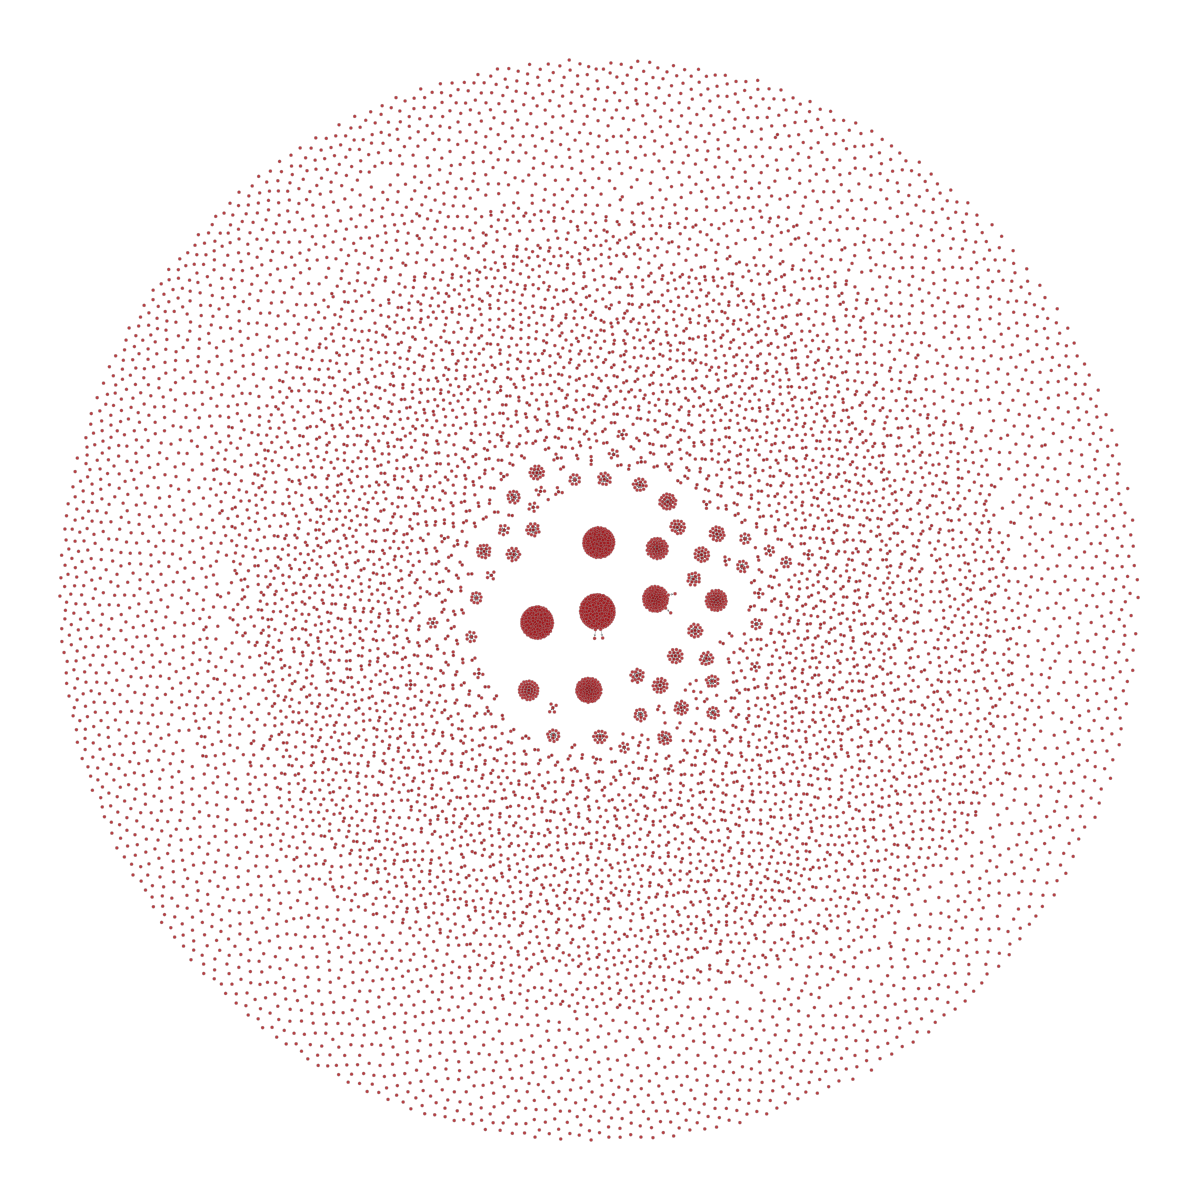

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x328bcc0e0, at 0x17b8975f0>

In [32]:
graph_draw(onion_mini.graph)

In [37]:
import lipinet.visualisation

In [42]:
extra_vars = ['layer', 'node_id']
for var in extra_vars:
    onion_mini.create_human_readable_property(
    encoded_prop_type='v', 
    encoded_prop_name=var, 
    mapping_dict=onion_mini.vertex_categorical_mappings[var]['int_to_str'], 
    new_prop_name=f'{var}_hr'
)

V property 'layer_hr' created successfully.
V property 'node_id_hr' created successfully.


10


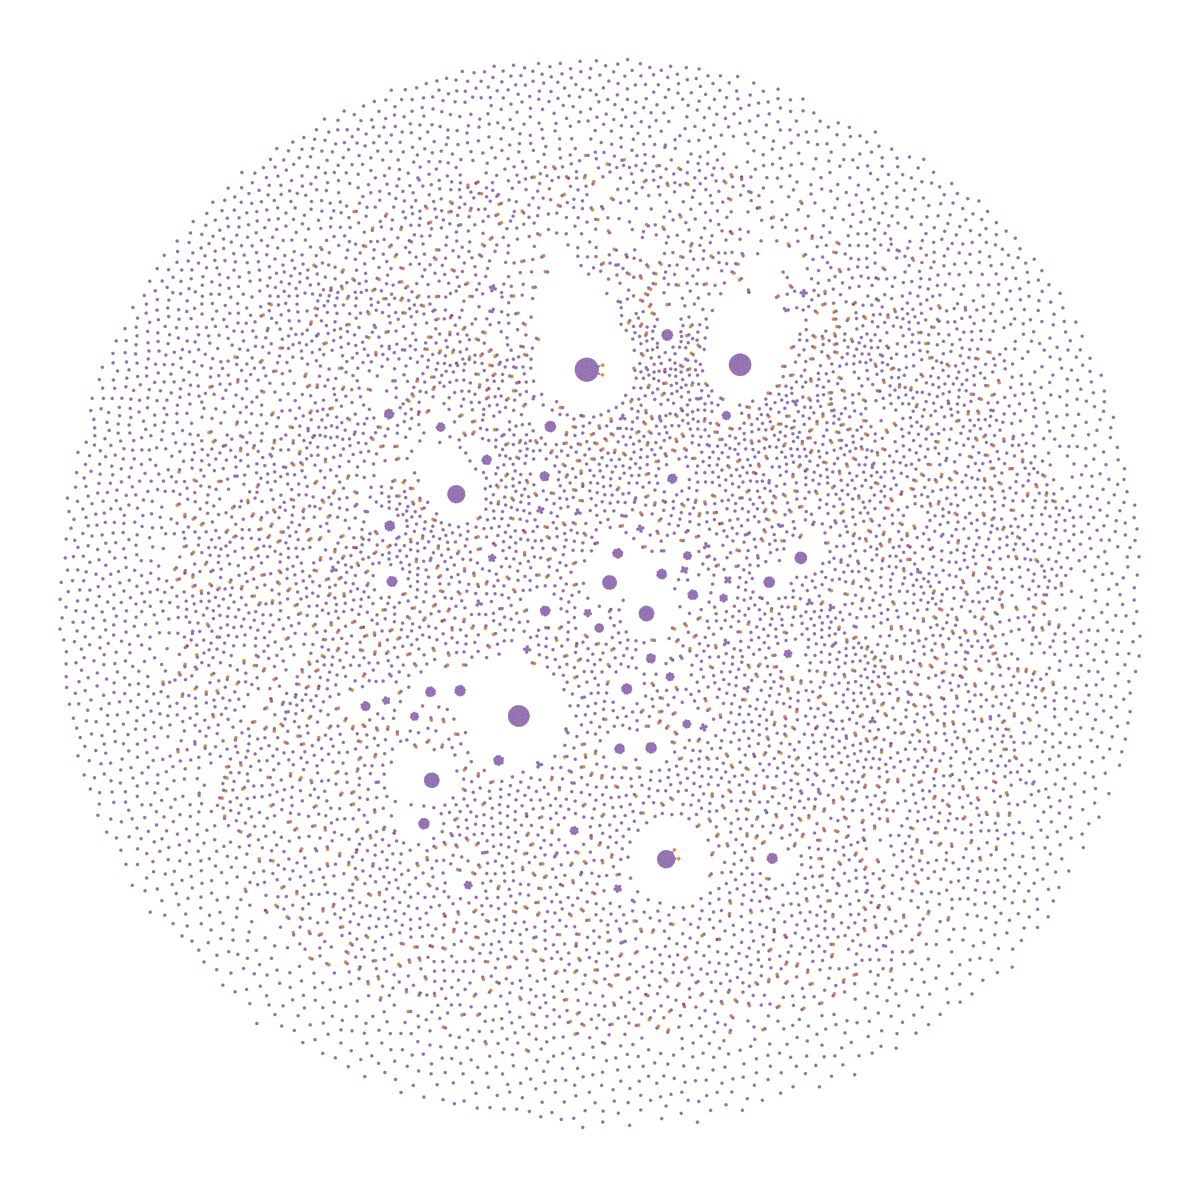

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x328bcc0e0, at 0x328c86840>

In [44]:
color_result = lipinet.visualisation.color_nodes(g=onion_mini.graph, prop_name="layer_hr", method="categorical", generate_legend=True)
shape_result = lipinet.visualisation.shape_nodes(g=onion_mini.graph, prop_name="layer_hr", shape_method="categorical")
# halo_result  = lipinet.visualisation.add_halo_to_node(g=onion.graph, node=noi)

node_styles = {**color_result, **shape_result} #, **halo_result}
node_styles

graph_draw(onion_mini.graph,
           vertex_fill_color=node_styles['v_color'])


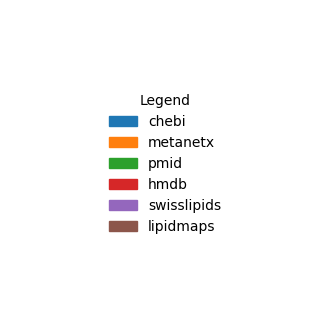

In [45]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

color_result['legend_node_color']

# Create a patch for each legend entry
patches = [mpatches.Patch(color=color, label=label) for label, color in color_result['legend_node_color'].items()]

# Create a figure and add the legend
fig, ax = plt.subplots(figsize=(4, 4))
ax.legend(handles=patches, loc='center', frameon=False, title="Legend")
ax.axis('off')  # Hide the axes

plt.show()